<a href="https://colab.research.google.com/github/williamfang0402/Consumer_Finance_Stress_Analysis/blob/main/datathon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Which Financial Products Are Most Sensitive to Economic Stress?
### Inflation, Interest Rates, and Consumer Complaint Behavior

**Research Question:**
Do spikes in inflation or interest rates coincide with more complaints about specific consumer finance products? Which products are most sensitive to which type of economic stress?

**Datasets:**
- CFPB Consumer Complaint Database (uploaded as `complaints.csv`)
- FRED Interest Rate series (uploaded as `interest.csv`)
- FRED CPI Inflation series (uploaded as `inflation.csv`)

**Panel structure:** One row per month × product
```
month | product | complaint_count | cpi_level | inflation_yoy | fedfunds_rate
```

| Section | What it does |
|---|---|
| 1 | Install & import libraries |
| 2 | Load & clean CFPB complaint data |
| 3 | Load macro data from CSV files |
| 4 | Build product-month panel (long format) |
| 5 | Exploratory Data Analysis (EDA) |
| 6 | Lag analysis |
| 7 | Sensitivity matrix |
| 8 | Regression modeling |
| 9 | ML model |
| 10 | Geographic analysis |
| 11 | Results summary |

---
## Section 1 — Install & Import Libraries

In [ ]:
!pip install pandas numpy matplotlib seaborn statsmodels scikit-learn requests tqdm scipy -q
print('Libraries installed successfully')

Libraries installed successfully


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.tsa.stattools import ccf
from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, r2_score
import warnings
from tqdm import tqdm

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.float_format', '{:.4f}'.format)

print('All libraries loaded successfully')

All libraries loaded successfully


---
## Section 2 — Load & Clean CFPB Complaint Data

Keeping fields: Date received, Product, Issue, Company, State

In [ ]:
PRODUCTS_NAMES = {
    'Mortgage':                      'Mortgage',
    'Credit card':                   'Credit Card',
    'Credit card or prepaid card':   'Credit Card',
    'Student loan':                  'Student Loan',
    'Checking or savings account':   'Checking/Savings',
    'Bank account or service':       'Checking/Savings',
    'Vehicle loan or lease':         'Vehicle Loan/Lease',
}

cfpb_raw = pd.read_csv(
    '/content/complaints.csv',
    usecols=['Date received', 'Product', 'Issue', 'Company', 'State'],
    parse_dates=['Date received'],
    low_memory=False
)
cfpb_raw.columns = ['date_received', 'product', 'issue', 'company', 'state']

cfpb_raw = cfpb_raw[(cfpb_raw['date_received'].dt.year >= 2019) & (cfpb_raw['date_received'].dt.year <= 2025)]

print(f'Raw complaints loaded: {len(cfpb_raw):,}')
print(f'\nRaw product names in file:')
print(cfpb_raw['product'].value_counts())

Raw complaints loaded: 274,018

Raw product names in file:
product
Checking or savings account    102508
Credit card                     64332
Mortgage                        57003
Vehicle loan or lease           25983
Student loan                    24192
Name: count, dtype: int64


In [ ]:
# Clean the data
cfpb = cfpb_raw.copy()
cfpb['date_received'] = pd.to_datetime(cfpb['date_received'], errors='coerce')
cfpb = cfpb.dropna(subset=['date_received', 'product'])
cfpb['product_clean'] = cfpb['product'].map(PRODUCTS_NAMES)
cfpb = cfpb.dropna(subset=['product_clean'])

cfpb['month'] = cfpb['date_received'].dt.to_period('M').dt.to_timestamp()

print(f'Cleaned complaints: {len(cfpb):,}')
print(f'Date range: {cfpb.date_received.min().date()} to {cfpb.date_received.max().date()}')
print(f'\nComplaints by product:')
print(cfpb['product_clean'].value_counts())
print(f'\nSample of kept fields (Date, Product, Issue, Company, State):')
cfpb[['date_received','product_clean','issue','company','state']].head(5)

Cleaned complaints: 274,018
Date range: 2019-01-01 to 2025-12-31

Complaints by product:
product_clean
Checking/Savings      102508
Credit Card            64332
Mortgage               57003
Vehicle Loan/Lease     25983
Student Loan           24192
Name: count, dtype: int64

Sample of kept fields (Date, Product, Issue, Company, State):


,date_received,product_clean,issue,company,state
0,2019-12-20,Checking/Savings,Managing an account,WELLS FARGO & COMPANY,FL
1,2019-01-09,Mortgage,Struggling to pay mortgage,PNC Bank N.A.,NaN
2,2020-03-29,Student Loan,Dealing with your lender or servicer,"Navient Solutions, LLC.",CA
3,2024-01-16,Credit Card,"Other features, terms, or problems",WELLS FARGO & COMPANY,TX
4,2020-06-05,Checking/Savings,Managing an account,"CITIBANK, N.A.",NY


---
## Section 3 — Load Macro Data from CSV Files

In [ ]:
fed_funds = pd.read_csv('/content/interest.csv')
fed_funds.columns = ['month', 'fedfunds_rate']
fed_funds['month'] = pd.to_datetime(fed_funds['month'])
fed_funds = fed_funds.set_index('month').resample('MS').last()
fed_funds['fedfunds_rate'] = pd.to_numeric(fed_funds['fedfunds_rate'], errors='coerce')
fed_funds['rate_change'] = fed_funds['fedfunds_rate'].diff()
fed_funds = fed_funds.reset_index()
print(f'Federal Funds Rate: {len(fed_funds)} monthly observations')

cpi = pd.read_csv('/content/inflation.csv')
cpi.columns = ['month', 'cpi_level']
cpi['month'] = pd.to_datetime(cpi['month'])
cpi = cpi.set_index('month').resample('MS').last()
cpi['cpi_level'] = pd.to_numeric(cpi['cpi_level'], errors='coerce')
cpi['inflation_yoy'] = cpi['cpi_level'].pct_change(12) * 100
cpi['inflation_mom'] = cpi['cpi_level'].pct_change(1) * 100
cpi = cpi.reset_index()
print(f'CPI Inflation:   {len(cpi)} monthly observations')

macro = pd.merge(fed_funds, cpi, on='month', how='inner')
macro = macro.dropna(subset=['fedfunds_rate', 'inflation_yoy'])
macro = macro.sort_values('month').reset_index(drop=True)

print(f'\nMacro panel: {len(macro)} monthly observations')
print(f'Date range: {macro.month.min().date()} to {macro.month.max().date()}')
print(f'Columns: {list(macro.columns)}')
macro.head()

Federal Funds Rate: 84 monthly observations
CPI Inflation:   84 monthly observations

Macro panel: 72 monthly observations
Date range: 2020-01-01 to 2025-12-01
Columns: ['month', 'fedfunds_rate', 'rate_change', 'cpi_level', 'inflation_yoy', 'inflation_mom']


,month,fedfunds_rate,rate_change,cpi_level,inflation_yoy,inflation_mom
0,2020-01-01,1.5500,0.0000,259.1270,2.5998,0.1922
1,2020-02-01,1.5800,0.0300,259.2500,2.3413,0.0475
2,2020-03-01,0.6500,-0.9300,258.0760,1.4940,-0.4528
3,2020-04-01,0.0500,-0.6000,256.0320,0.3130,-0.7920
4,2020-05-01,0.0500,0.0000,255.8020,0.1982,-0.0898


---
## Section 4 — Build Product-Month Panel (Long Format)

Final structure: **one row per month × product**

| month | product | complaint_count | cpi_level | inflation_yoy | fedfunds_rate | ... |
|---|---|---|---|---|---|---|

In [ ]:
complaint_long = (
    cfpb.groupby(['month', 'product_clean'])
    .size()
    .reset_index(name='complaint_count')
    .rename(columns={'product_clean': 'product'})
)

all_months = sorted(macro['month'].unique())
all_products = sorted(cfpb['product_clean'].dropna().unique())

full_index = pd.MultiIndex.from_product(
    [all_months, all_products],
    names=['month', 'product']
)

complaint_long = (
    complaint_long
    .set_index(['month', 'product'])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

print(f'Long complaint panel: {len(complaint_long)} rows')
print(complaint_long.head(8))

panel_long = pd.merge(complaint_long, macro, on='month', how='inner')
panel_long = panel_long.sort_values(['product', 'month']).reset_index(drop=True)

for col in ['fedfunds_rate', 'inflation_yoy', 'rate_change']:
    for lag in [1, 2, 3]:
        panel_long[f'{col}_lag{lag}'] = panel_long.groupby('product')[col].shift(lag)

panel_long['month_num'] = panel_long['month'].dt.month
panel_long['year'] = panel_long['month'].dt.year

panel_long = panel_long.dropna().reset_index(drop=True)

products = sorted(panel_long['product'].unique().tolist())

print(f'\nFinal panel_long: {len(panel_long)} rows')
print(f'Products: {products}')
print(f'Date range: {panel_long.month.min().date()} to {panel_long.month.max().date()}')
print(f'Columns: {list(panel_long.columns)}')
panel_long.head(10)

Long complaint panel: 360 rows
       month             product  complaint_count
0 2020-01-01    Checking/Savings              657
1 2020-01-01         Credit Card                0
2 2020-01-01            Mortgage              625
3 2020-01-01        Student Loan              180
4 2020-01-01  Vehicle Loan/Lease              141
5 2020-02-01    Checking/Savings              570
6 2020-02-01         Credit Card                0
7 2020-02-01            Mortgage              618

Final panel_long: 340 rows
Products: ['Checking/Savings', 'Credit Card', 'Mortgage', 'Student Loan', 'Vehicle Loan/Lease']
Date range: 2020-04-01 to 2025-12-01
Columns: ['month', 'product', 'complaint_count', 'fedfunds_rate', 'rate_change', 'cpi_level', 'inflation_yoy', 'inflation_mom', 'fedfunds_rate_lag1', 'fedfunds_rate_lag2', 'fedfunds_rate_lag3', 'inflation_yoy_lag1', 'inflation_yoy_lag2', 'inflation_yoy_lag3', 'rate_change_lag1', 'rate_change_lag2', 'rate_change_lag3', 'month_num', 'year']


,month,product,complaint_count,fedfunds_rate,rate_change,cpi_level,inflation_yoy,inflation_mom,fedfunds_rate_lag1,fedfunds_rate_lag2,fedfunds_rate_lag3,inflation_yoy_lag1,inflation_yoy_lag2,inflation_yoy_lag3,rate_change_lag1,rate_change_lag2,rate_change_lag3,month_num,year
0,2020-04-01,Checking/Savings,701,0.0500,-0.6000,256.0320,0.3130,-0.7920,0.6500,1.5800,1.5500,1.4940,2.3413,2.5998,-0.9300,0.0300,0.0000,4,2020
1,2020-05-01,Checking/Savings,670,0.0500,0.0000,255.8020,0.1982,-0.0898,0.0500,0.6500,1.5800,0.3130,1.4940,2.3413,-0.6000,-0.9300,0.0300,5,2020
2,2020-06-01,Checking/Savings,799,0.0800,0.0300,257.0420,0.7167,0.4847,0.0500,0.0500,0.6500,0.1982,0.3130,1.4940,0.0000,-0.6000,-0.9300,6,2020
3,2020-07-01,Checking/Savings,899,0.0900,0.0100,258.3520,0.9969,0.5096,0.0800,0.0500,0.0500,0.7167,0.1982,0.3130,0.0300,0.0000,-0.6000,7,2020
4,2020-08-01,Checking/Savings,692,0.1000,0.0100,259.3160,1.2811,0.3731,0.0900,0.0800,0.0500,0.9969,0.7167,0.1982,0.0100,0.0300,0.0000,8,2020
5,2020-09-01,Checking/Savings,758,0.0900,-0.0100,259.9970,1.3910,0.2626,0.1000,0.0900,0.0800,1.2811,0.9969,0.7167,0.0100,0.0100,0.0300,9,2020
6,2020-10-01,Checking/Savings,696,0.0900,0.0000,260.3190,1.2304,0.1238,0.0900,0.1000,0.0900,1.3910,1.2811,0.9969,-0.0100,0.0100,0.0100,10,2020
7,2020-11-01,Checking/Savings,632,0.0900,0.0000,260.9110,1.1757,0.2274,0.0900,0.0900,0.1000,1.2304,1.3910,1.2811,0.0000,-0.0100,0.0100,11,2020
8,2020-12-01,Checking/Savings,723,0.0900,0.0000,262.0450,1.3204,0.4346,0.0900,0.0900,0.0900,1.1757,1.2304,1.3910,0.0000,0.0000,-0.0100,12,2020
9,2021-01-01,Checking/Savings,774,0.0900,0.0000,262.6870,1.3738,0.2450,0.0900,0.0900,0.0900,1.3204,1.1757,1.2304,0.0000,0.0000,0.0000,1,2021


---
## Section 5 — Exploratory Data Analysis (EDA)

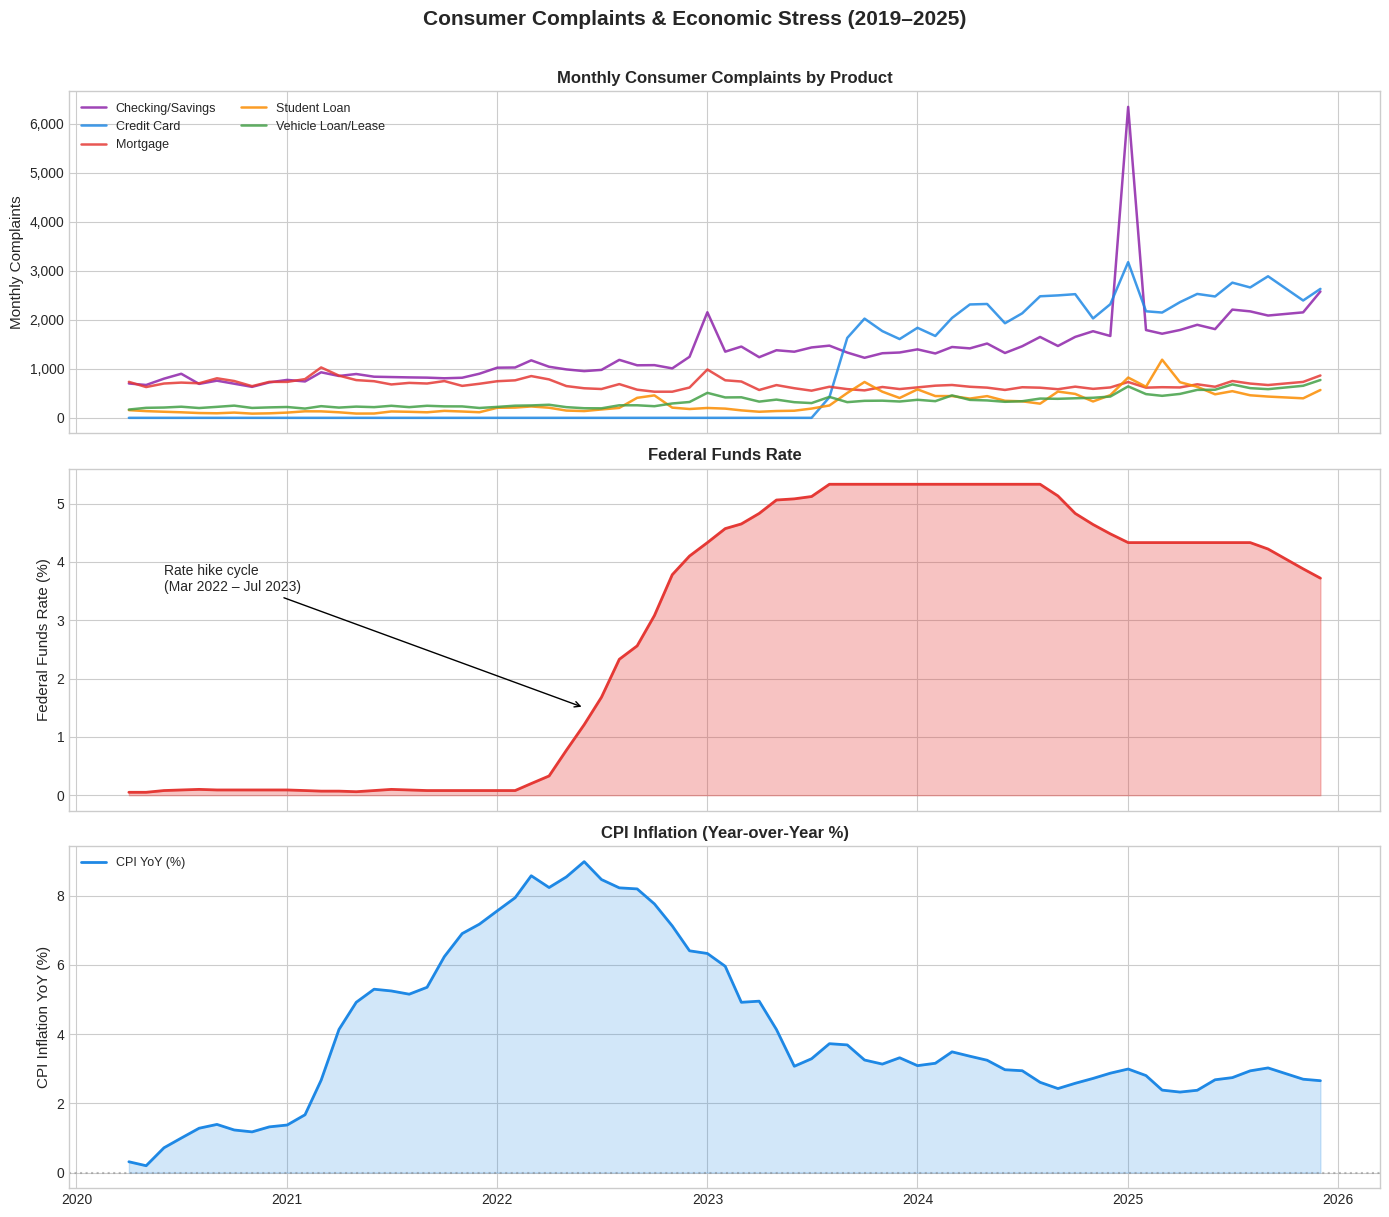

In [ ]:
PRODUCT_COLORS = {
    'Mortgage': '#E53935',
    'Credit Card': '#1E88E5',
    'Student Loan': '#FB8C00',
    'Checking/Savings': '#8E24AA',
    'Vehicle Loan/Lease': '#43A047'
}

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

plot1 = axes[0]
for product in products:
    subset = panel_long[panel_long['product'] == product]
    color = PRODUCT_COLORS.get(product, 'gray')
    plot1.plot(subset['month'], subset['complaint_count'], label=product, color=color, linewidth=1.8, alpha=0.85)
plot1.set_ylabel('Monthly Complaints', fontsize=11)
plot1.set_title('Monthly Consumer Complaints by Product', fontsize=12, fontweight='bold')
plot1.legend(loc='upper left', fontsize=9, ncol=2)
plot1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))


plot2 = axes[1]
rate_data = panel_long[panel_long['product'] == products[0]].sort_values('month')
plot2.fill_between(rate_data['month'], rate_data['fedfunds_rate'], alpha=0.3, color='#E53935')
plot2.plot(rate_data['month'], rate_data['fedfunds_rate'], color='#E53935', linewidth=2)
plot2.set_ylabel('Federal Funds Rate (%)', fontsize=11)
plot2.set_title('Federal Funds Rate', fontsize=12, fontweight='bold')
plot2.annotate('Rate hike cycle\n(Mar 2022 – Jul 2023)', xy=(pd.Timestamp('2022-06-01'), 1.5), xytext=(pd.Timestamp('2020-06-01'), 3.5),
               arrowprops=dict(arrowstyle='->', color='black'))


plot3 = axes[2]
plot3.fill_between(rate_data['month'], rate_data['inflation_yoy'], alpha=0.2, color='#1E88E5')
plot3.plot(rate_data['month'], rate_data['inflation_yoy'], color='#1E88E5', linewidth=2, label='CPI YoY (%)')
plot3.set_ylabel('CPI Inflation YoY (%)', fontsize=11)
plot3.set_title('CPI Inflation (Year-over-Year %)', fontsize=12, fontweight='bold')
plot3.axhline(0, color='gray', linestyle=':', alpha=0.5)
plot3.legend(loc='upper left', fontsize=9)

plt.suptitle('Consumer Complaints & Economic Stress (2019–2025)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

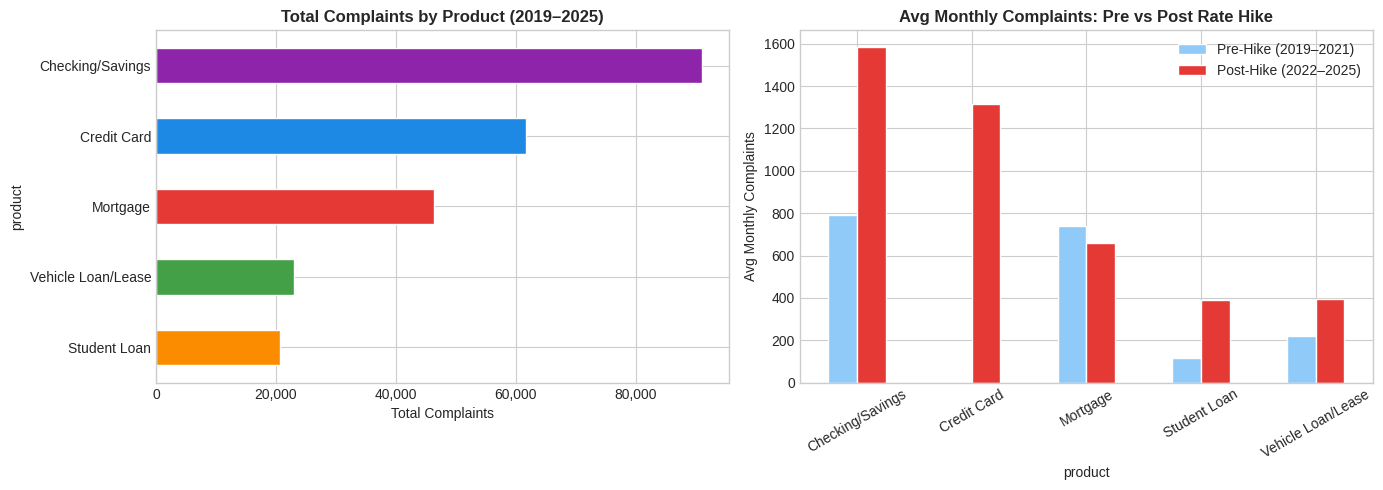


Percentage change pre vs post rate hike:
  Student Loan             : +238.5%
  Checking/Savings         : +100.3%
  Vehicle Loan/Lease       : +80.4%
  Mortgage                 : -11.2%


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

total_by_product = (panel_long.groupby('product')['complaint_count'].sum().sort_values(ascending=True))
colors = [PRODUCT_COLORS.get(p, 'gray') for p in total_by_product.index]
total_by_product.plot(kind='barh', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Total Complaints by Product (2019–2025)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Total Complaints')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

pre = panel_long[panel_long['year'] <= 2021].groupby('product')['complaint_count'].mean()
post = panel_long[panel_long['year'] >= 2022].groupby('product')['complaint_count'].mean()
comparison = pd.DataFrame({'Pre-Hike (2019–2021)': pre, 'Post-Hike (2022–2025)': post})
comparison.plot(kind='bar', ax=axes[1], color=['#90CAF9', '#E53935'], edgecolor='white')
axes[1].set_title('Avg Monthly Complaints: Pre vs Post Rate Hike', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Avg Monthly Complaints')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()

plt.tight_layout()
plt.show()

print('\nPercentage change pre vs post rate hike:')
percentage_change = ((post - pre) / pre * 100).replace([np.inf, -np.inf], np.nan).dropna().sort_values(ascending=False)
for product, value in percentage_change.items():
    print(f'  {product:25s}: {value:+.1f}%')

---
## Section 6 — Lag Analysis

Do complaints respond immediately to macro stress, or with a 1–3 month delay?

In [ ]:
MACRO_VARS = ['fedfunds_rate', 'inflation_yoy']

def compute_lagged_correlations(panel_long, products, macro_vars, max_lag=6):
    results = []
    for product in products:
        subset = panel_long[panel_long['product'] == product].sort_values('month')
        for macro in macro_vars:
            if macro not in subset.columns:
                continue
            for lag in range(0, max_lag + 1):
                complaint_s = subset['complaint_count'].values
                macro_s = subset[macro].shift(lag).values
                mask = ~np.isnan(macro_s) & ~np.isnan(complaint_s)
                if mask.sum() < 10:
                    continue
                correlation, p_vlaue = stats.pearsonr(complaint_s[mask], macro_s[mask])
                results.append({
                    'product': product, 'macro_var': macro, 'lag': lag, 'correlation': correlation,
                    'p_value': p_value, 'significant': p_value < 0.05
                })
    return pd.DataFrame(results)


lag_results = compute_lagged_correlations(panel_long, products, MACRO_VARS, max_lag=6)

print(f'Lag correlations computed: {len(lag_results)} combinations')

best_lags = (
    lag_results
    .assign(abs_corr=lambda x: x['correlation'].abs())
    .sort_values('abs_corr', ascending=False)
    .groupby(['product', 'macro_var'], as_index=False)
    .first()
    .drop(columns='abs_corr')
    .sort_values(['macro_var', 'correlation'], ascending=[True, False])
)

print('\nBest lag for each product × stressor:')
print(best_lags[['product','macro_var','lag','correlation','p_value']].to_string(index=False))

Lag correlations computed: 70 combinations

Best lag for each product × stressor:
           product     macro_var  lag  correlation  p_value
       Credit Card fedfunds_rate    6       0.8589   0.0467
      Student Loan fedfunds_rate    6       0.7111   0.0467
Vehicle Loan/Lease fedfunds_rate    5       0.6968   0.0467
  Checking/Savings fedfunds_rate    5       0.5418   0.0467
          Mortgage fedfunds_rate    0      -0.4814   0.0467
  Checking/Savings inflation_yoy    0      -0.1233   0.0467
      Student Loan inflation_yoy    0      -0.2155   0.0467
Vehicle Loan/Lease inflation_yoy    0      -0.2421   0.0467
          Mortgage inflation_yoy    5      -0.2428   0.0467
       Credit Card inflation_yoy    3      -0.4101   0.0467


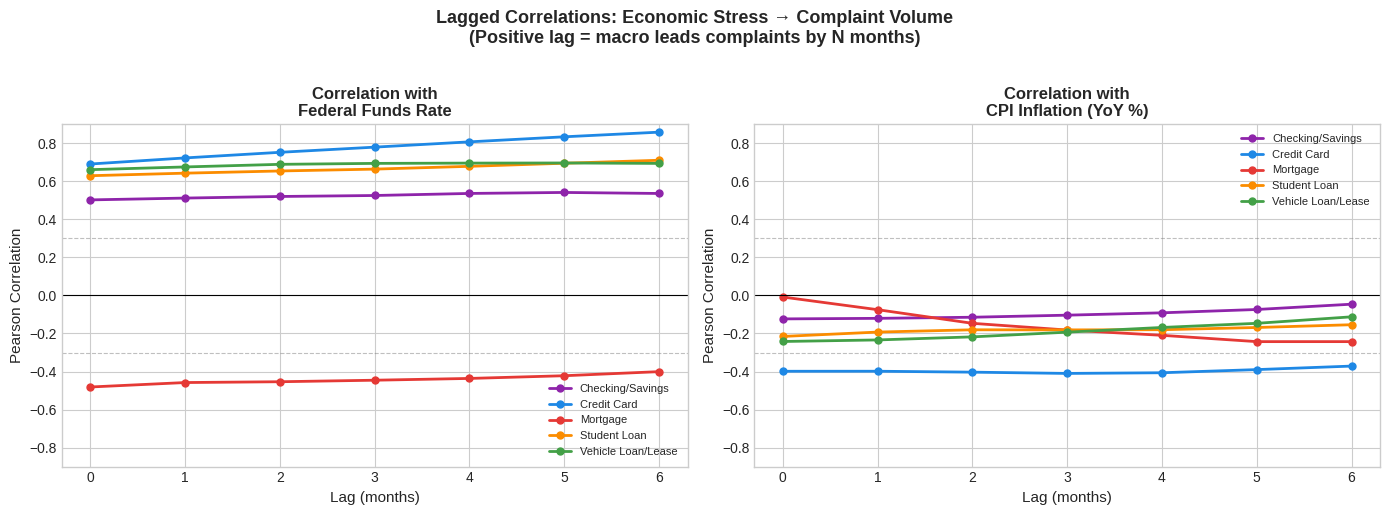

In [ ]:
macro_titles = {'fedfunds_rate': 'Federal Funds Rate', 'inflation_yoy': 'CPI Inflation (YoY %)'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, macro in zip(axes, MACRO_VARS):
    subset = lag_results[lag_results['macro_var'] == macro]
    for prod in products:
        prod_data = subset[subset['product'] == prod].sort_values('lag')
        if prod_data.empty:
            continue
        color = PRODUCT_COLORS.get(prod, 'gray')
        ax.plot(prod_data['lag'], prod_data['correlation'],
                marker='o', label=prod, color=color, linewidth=2, markersize=5)
    ax.axhline(0,    color='black', linewidth=0.8)
    ax.axhline(0.3,  color='gray',  linewidth=0.8, linestyle='--', alpha=0.5)
    ax.axhline(-0.3, color='gray',  linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_xlabel('Lag (months)', fontsize=11)
    ax.set_ylabel('Pearson Correlation', fontsize=11)
    ax.set_title(f'Correlation with\n{macro_titles[macro]}', fontsize=12, fontweight='bold')
    ax.set_xticks(range(0, 7))
    ax.legend(fontsize=8)
    ax.set_ylim(-0.9, 0.9)

plt.suptitle('Lagged Correlations: Economic Stress → Complaint Volume\n(Positive lag = macro leads complaints by N months)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Section 7 — Sensitivity Matrix

Centerpiece result: which products are most sensitive to which stressors?

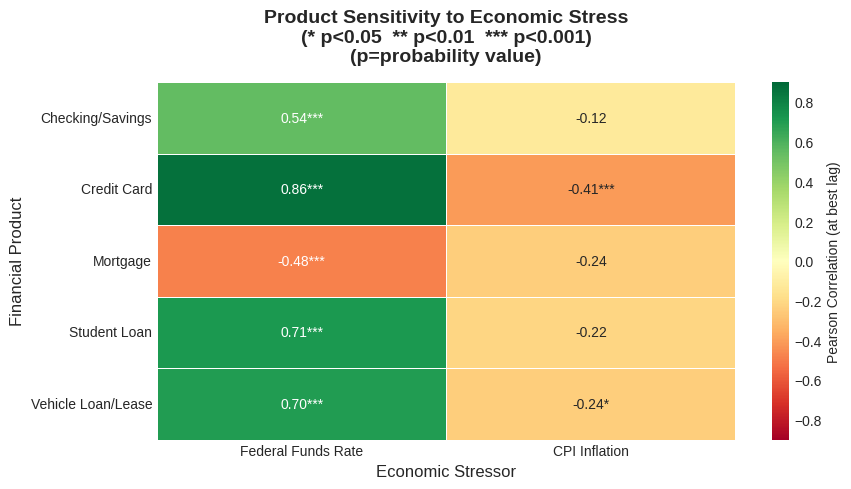


Sensitivity Matrix:
                    Federal Funds Rate  CPI Inflation
product                                              
Checking/Savings                0.5420        -0.1230
Credit Card                     0.8590        -0.4100
Mortgage                       -0.4810        -0.2430
Student Loan                    0.7110        -0.2160
Vehicle Loan/Lease              0.6970        -0.2420


In [ ]:
sensitivity_matrix = best_lags.pivot(index='product', columns='macro_var', values='correlation')

col_rename = {'fedfunds_rate': 'Federal Funds Rate', 'inflation_yoy': 'CPI Inflation'}
sensitivity_matrix.columns = [col_rename.get(c, c) for c in sensitivity_matrix.columns]

pval_matrix = best_lags.pivot(index='product', columns='macro_var', values='p_value')

annot_matrix = sensitivity_matrix.copy().astype(str)
for product in sensitivity_matrix.index:
    for disp_col, raw_col in [('Federal Funds Rate','fedfunds_rate'), ('CPI Inflation','inflation_yoy')]:
        if disp_col in sensitivity_matrix.columns and raw_col in pval_matrix.columns:
            correlation = sensitivity_matrix.loc[product, disp_col]
            p_value = pval_matrix.loc[product, raw_col]
            stars = '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else ''
            annot_matrix.loc[product, disp_col] = f'{correlation:.2f}{stars}'

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(sensitivity_matrix,annot=annot_matrix, fmt='',cmap='RdYlGn', center=0, vmin=-0.9, vmax=0.9,
    linewidths=0.5, linecolor='white', ax=ax, cbar_kws={'label': 'Pearson Correlation (at best lag)'})
ax.set_title('Product Sensitivity to Economic Stress\n(* p<0.05  ** p<0.01  *** p<0.001)\n(p=probability value)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Economic Stressor', fontsize=12)
ax.set_ylabel('Financial Product', fontsize=12)
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()
print('\nSensitivity Matrix:')
print(sensitivity_matrix.round(3))

---
## Section 8 — Regression Modeling

OLS regression per product using the long panel. Each model estimates: `complaint_count ~ fedfunds_rate_lag2 + inflation_yoy_lag2 + rate_change_lag2 + month_fixed_effects`

In [ ]:
print('Running OLS regressions...\n')
ols_results = {}

REGRESSION_FEATURES = ['fedfunds_rate_lag2', 'inflation_yoy_lag2', 'rate_change_lag2']

for prod in products:
    try:
        subset = panel_long[panel_long['product'] == prod].copy()

        month_dummies = pd.get_dummies(subset['month_num'], prefix='month', drop_first=True)
        model_df = pd.concat([subset[['complaint_count'] + REGRESSION_FEATURES].reset_index(drop=True),
                               month_dummies.reset_index(drop=True)], axis=1).dropna()

        all_features = REGRESSION_FEATURES + list(month_dummies.columns)
        model_df = model_df.rename(columns={'complaint_count': 'y'})
        formula = 'y ~ ' + ' + '.join(all_features)

        model = smf.ols(formula, data=model_df).fit()
        ols_results[prod] = model

        sig = sum(1 for f in REGRESSION_FEATURES if model.pvalues.get(f, 1) < 0.05)
        print(f'  {prod:25s} | R²={model.rsquared:.3f} | {sig}/{len(REGRESSION_FEATURES)} macro vars significant')

    except Exception as e:
        print(f'  {prod}: {e}')

print(f'\nOLS complete — {len(ols_results)} models fitted')

Running OLS regressions...

  Checking/Savings          | R²=0.443 | 1/3 macro vars significant
  Credit Card               | R²=0.702 | 2/3 macro vars significant
  Mortgage                  | R²=0.502 | 2/3 macro vars significant
  Student Loan              | R²=0.544 | 1/3 macro vars significant
  Vehicle Loan/Lease        | R²=0.522 | 1/3 macro vars significant

✅ OLS complete — 5 models fitted


In [ ]:
macro_display = {
    'fedfunds_rate_lag2': 'Fed Funds Rate (lag 2)',
    'inflation_yoy_lag2': 'CPI Inflation (lag 2)',
    'rate_change_lag2':   'Rate Change (lag 2)',
}

rows = []
for prod, model in ols_results.items():
    row = {'Product': prod, 'R²': round(model.rsquared, 3)}
    for col, display in macro_display.items():
        if col in model.params:
            coef  = model.params[col]
            pval  = model.pvalues[col]
            stars = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
            row[display] = f'{coef:+.1f}{stars}'
        else:
            row[display] = 'N/A'
    rows.append(row)

results_table = pd.DataFrame(rows).set_index('Product')
print('OLS Regression Summary')
print('Coefficient = change in monthly complaints per unit increase in stressor')
print('* p<0.05  ** p<0.01  *** p<0.001\n')
print(results_table.to_string())

OLS Regression Summary
Coefficient = change in monthly complaints per unit increase in stressor
* p<0.05  ** p<0.01  *** p<0.001

                       R² Fed Funds Rate (lag 2) CPI Inflation (lag 2) Rate Change (lag 2)
Product                                                                                   
Checking/Savings   0.4430              +183.8***                 +32.9              -685.9
Credit Card        0.7020              +380.7***                 -41.4           -1498.8**
Mortgage           0.5020               -22.3***               -15.5**              +100.9
Student Loan       0.5440               +65.9***                  +7.2              -247.2
Vehicle Loan/Lease 0.5220               +42.0***                  -2.8               -50.4


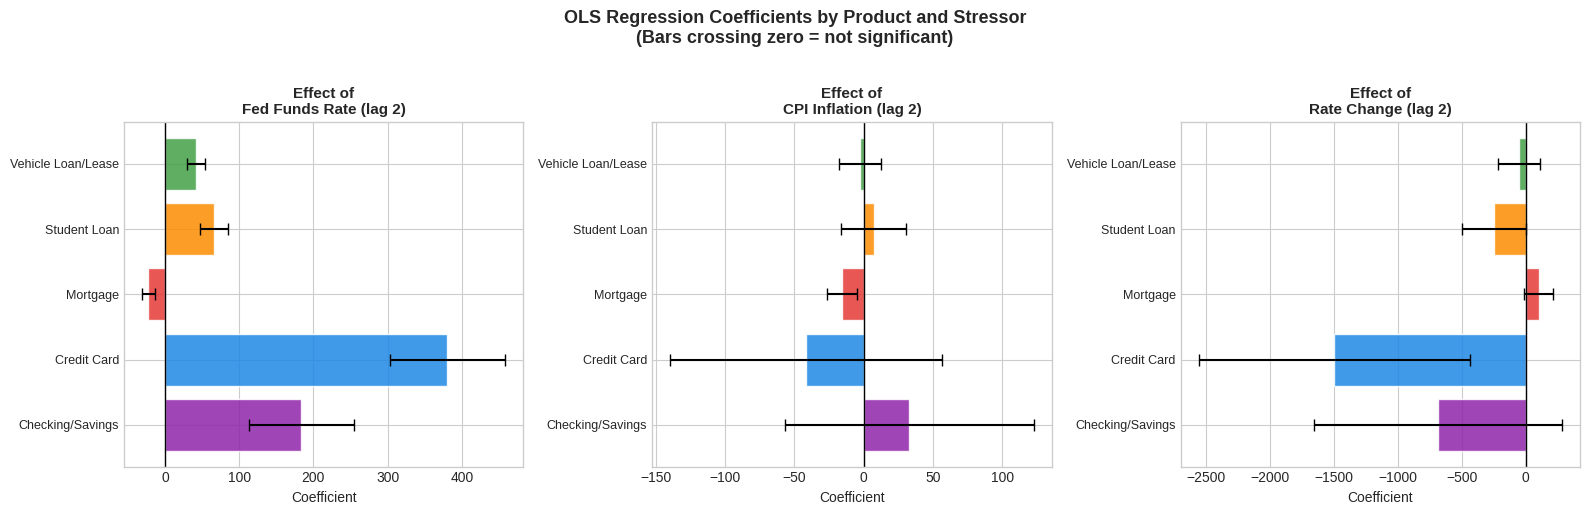

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (col, display) in zip(axes, macro_display.items()):
    coefs, ci_low, ci_high, prod_labels = [], [], [], []
    for prod, model in ols_results.items():
        if col in model.params:
            coefs.append(model.params[col])
            ci = model.conf_int().loc[col]
            ci_low.append(ci[0])
            ci_high.append(ci[1])
            prod_labels.append(prod)
    if not coefs:
        ax.set_visible(False)
        continue
    colors = [PRODUCT_COLORS.get(p, 'gray') for p in prod_labels]
    y_pos  = range(len(coefs))
    ax.barh(y_pos, coefs, color=colors, edgecolor='white', alpha=0.85)
    ax.errorbar(coefs, y_pos,
                xerr=[np.array(coefs)-np.array(ci_low), np.array(ci_high)-np.array(coefs)],
                fmt='none', color='black', capsize=4, linewidth=1.5)
    ax.axvline(0, color='black', linewidth=1)
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(prod_labels, fontsize=9)
    ax.set_xlabel('Coefficient', fontsize=10)
    ax.set_title(f'Effect of\n{display}', fontsize=11, fontweight='bold')

plt.suptitle('OLS Regression Coefficients by Product and Stressor\n(Bars crossing zero = not significant)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Section 9 — ML Model: Forecasting Complaint Surges

In [ ]:
ML_FEATURES = [
    'fedfunds_rate', 'inflation_yoy', 'rate_change',
    'fedfunds_rate_lag1', 'fedfunds_rate_lag2', 'fedfunds_rate_lag3',
    'inflation_yoy_lag1', 'inflation_yoy_lag2', 'inflation_yoy_lag3',
    'rate_change_lag1',   'rate_change_lag2',   'rate_change_lag3',
    'month_num'
]

ml_results = {}
print('Training Random Forest models...\n')

for prod in products:
    subset = panel_long[panel_long['product'] == prod].sort_values('month').copy()
    subset['target'] = subset['complaint_count'].shift(-1)  # predict next month
    subset = subset.dropna(subset=['target'] + ML_FEATURES)

    X = subset[ML_FEATURES].values
    y = subset['target'].values
    dates = subset['month'].values

    if len(X) < 20:
        print(f'  {prod}: not enough data ({len(X)} rows)')
        continue

    tscv = TimeSeriesSplit(n_splits=3)
    rf   = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)

    mae_scores, r2_scores = [], []
    all_preds, all_true, all_dates = [], [], []

    for train_idx, test_idx in tscv.split(X):
        rf.fit(X[train_idx], y[train_idx])
        preds = rf.predict(X[test_idx])
        mae_scores.append(mean_absolute_error(y[test_idx], preds))
        r2_scores.append(r2_score(y[test_idx], preds))
        all_preds.extend(preds)
        all_true.extend(y[test_idx])
        all_dates.extend(dates[test_idx])

    rf.fit(X, y)
    importances = pd.Series(rf.feature_importances_, index=ML_FEATURES).sort_values(ascending=False)

    ml_results[prod] = {
        'mae': np.mean(mae_scores),
        'r2':  np.mean(r2_scores),
        'importances': importances,
        'predictions': list(zip(all_dates, all_true, all_preds))
    }
    print(f'  {prod:25s} | MAE={np.mean(mae_scores):.1f} | R²={np.mean(r2_scores):.3f}')

print(f'\nML models complete')

Training Random Forest models...

  Checking/Savings          | MAE=425.2 | R²=-2.105
  Credit Card               | MAE=1108.1 | R²=-19.895
  Mortgage                  | MAE=101.3 | R²=-4.967
  Student Loan              | MAE=231.3 | R²=-2.142
  Vehicle Loan/Lease        | MAE=88.3 | R²=-1.379

✅ ML models complete


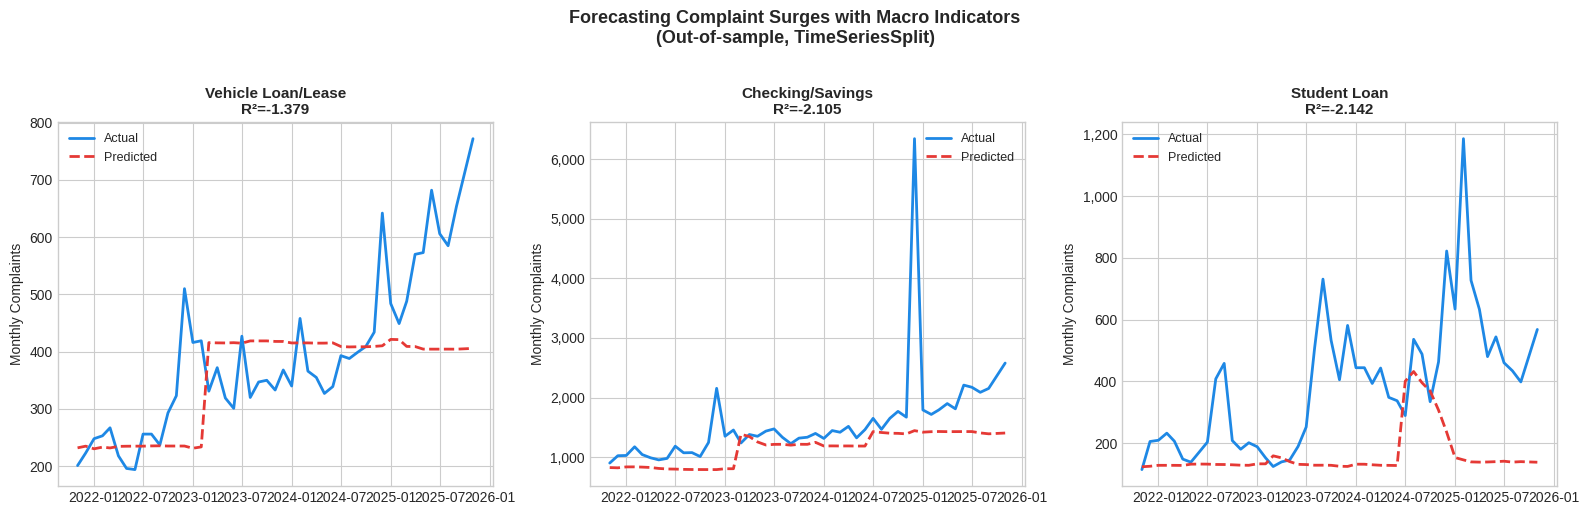

In [ ]:
top_products = sorted(ml_results.keys(), key=lambda p: ml_results[p]['r2'], reverse=True)[:3]

fig, axes = plt.subplots(1, len(top_products), figsize=(16, 5))
if len(top_products) == 1:
    axes = [axes]

for ax, prod in zip(axes, top_products):
    preds_data = ml_results[prod]['predictions']
    if not preds_data:
        continue
    dates_p, true_vals, pred_vals = zip(*preds_data)
    ax.plot(dates_p, true_vals, label='Actual',    color='#1E88E5', linewidth=2)
    ax.plot(dates_p, pred_vals, label='Predicted', color='#E53935', linewidth=2, linestyle='--')
    ax.set_title(f'{prod}\nR²={ml_results[prod]["r2"]:.3f}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Monthly Complaints')
    ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Forecasting Complaint Surges with Macro Indicators\n(Out-of-sample, TimeSeriesSplit)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

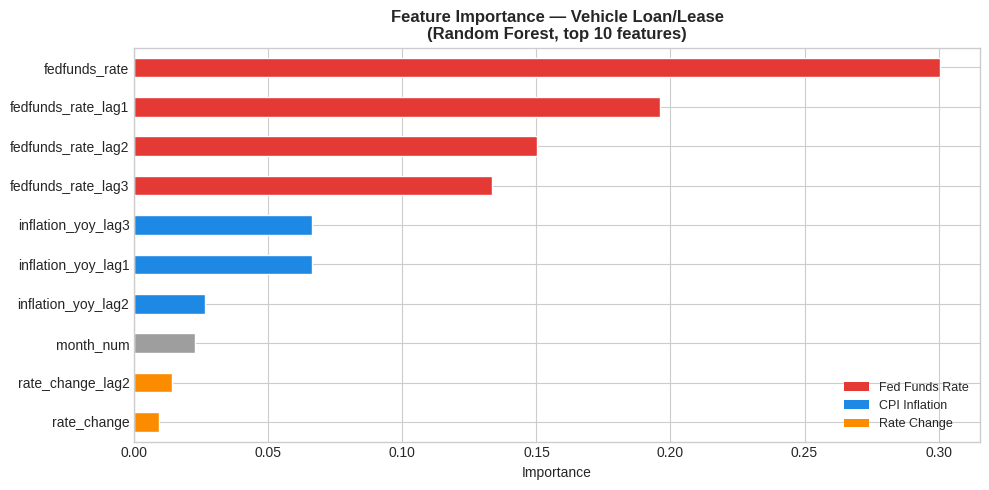

In [ ]:
if ml_results:
    best_prod = max(ml_results, key=lambda p: ml_results[p]['r2'])
    imp = ml_results[best_prod]['importances'].head(10)

    fig, ax = plt.subplots(figsize=(10, 5))
    feature_colors = [
        '#E53935' if 'fedfunds' in f
        else '#1E88E5' if 'inflation' in f
        else '#FB8C00' if 'rate_change' in f
        else '#9E9E9E'
        for f in imp.index
    ]
    imp[::-1].plot(kind='barh', ax=ax, color=feature_colors[::-1], edgecolor='white')
    ax.set_title(f'Feature Importance — {best_prod}\n(Random Forest, top 10 features)',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance')

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#E53935', label='Fed Funds Rate'),
        Patch(facecolor='#1E88E5', label='CPI Inflation'),
        Patch(facecolor='#FB8C00', label='Rate Change'),
    ]
    ax.legend(handles=legend_elements, fontsize=9)
    plt.tight_layout()
    plt.show()

---
## Section 10 — Geographic Analysis

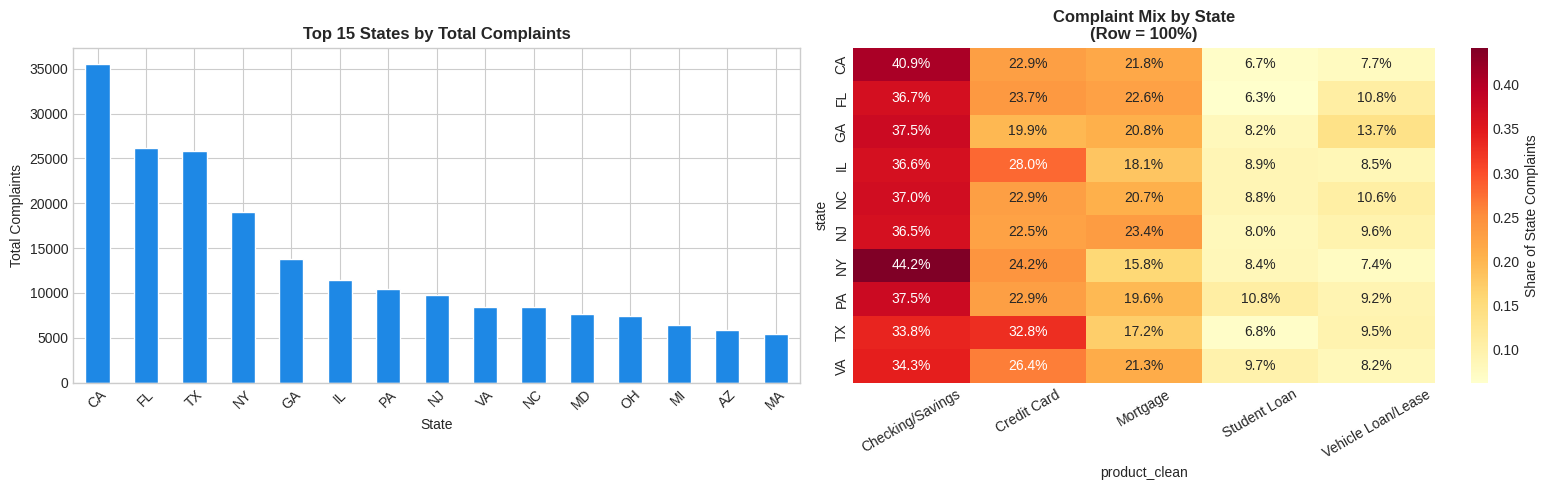

In [ ]:
if 'state' in cfpb.columns:
    state_counts = cfpb.groupby('state').size().sort_values(ascending=False).head(15)
    state_product = (
        cfpb[cfpb['state'].isin(state_counts.index[:10])]
        .groupby(['state', 'product_clean'])
        .size()
        .unstack(fill_value=0)
    )

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    state_counts.plot(kind='bar', ax=axes[0], color='#1E88E5', edgecolor='white')
    axes[0].set_title('Top 15 States by Total Complaints', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('State')
    axes[0].set_ylabel('Total Complaints')
    axes[0].tick_params(axis='x', rotation=45)

    state_product_norm = state_product.div(state_product.sum(axis=1), axis=0)
    sns.heatmap(state_product_norm, annot=True, fmt='.1%', cmap='YlOrRd',
                ax=axes[1], cbar_kws={'label': 'Share of State Complaints'})
    axes[1].set_title('Complaint Mix by State\n(Row = 100%)', fontsize=12, fontweight='bold')
    axes[1].tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.show()
else:
    print('State column not available — skipping geographic analysis')

---
## Section 11 — Final Results Summary

In [ ]:
print('=' * 65)
print('  FINAL RESULTS SUMMARY')
print('=' * 65)
print(f'  Dataset:       {len(cfpb):,} complaints, {len(products)} products')
print(f'  Date range:    {panel_long.month.min().date()} to {panel_long.month.max().date()}')
print(f'  Observations:  {len(panel_long)} product-month rows')
print()
print('  PANEL STRUCTURE (product-month long format)')
print('  ' + '-' * 60)
print(f'  {panel_long[["month","product","complaint_count","cpi_level","inflation_yoy","fedfunds_rate"]].head(3).to_string()}')
print()
print('  HYPOTHESIS RESULTS')
print('  ' + '-' * 60)
print('  H1: Debt products see more complaints during rate hikes')
for prod, model in ols_results.items():
    col = 'fedfunds_rate_lag2'
    if col in model.params:
        coef = model.params[col]
        pval = model.pvalues[col]
        sig  = 'Significant' if pval < 0.05 else '— Not significant'
        print(f'    {prod:25s}: coef={coef:+.1f}, p={pval:.3f}  {sig}')
print()
print('  H2: Effect is lagged (peaks 1-3 months after stress)')
for _, row in best_lags[best_lags['macro_var']=='fedfunds_rate'].iterrows():
    print(f'    {row["product"]:25s}: best lag = {row["lag"]} months, r={row["correlation"]:.2f}')
print()
print('  H3: Products differ in which stressor they respond to')
print('  (See sensitivity_matrix.png)')
print()
print('  ML MODEL PERFORMANCE (R²)')
for prod, res in sorted(ml_results.items(), key=lambda x: x[1]['r2'], reverse=True):
    print(f'    {prod:25s}: R²={res["r2"]:.3f}, MAE={res["mae"]:.1f}')
print()
print('  CHARTS SAVED:')
for c in ['eda_hero_chart.png','eda_product_breakdown.png','lag_analysis.png',
          'sensitivity_matrix.png','regression_coefficients.png',
          'ml_predictions.png','feature_importance.png','geographic_analysis.png']:
    print(f'    {c}')
print('=' * 65)

  FINAL RESULTS SUMMARY
  Dataset:       274,018 complaints, 5 products
  Date range:    2020-04-01 to 2025-12-01
  Observations:  340 product-month rows

  PANEL STRUCTURE (product-month long format)
  ------------------------------------------------------------
         month           product  complaint_count  cpi_level  inflation_yoy  fedfunds_rate
0 2020-04-01  Checking/Savings              701   256.0320         0.3130         0.0500
1 2020-05-01  Checking/Savings              670   255.8020         0.1982         0.0500
2 2020-06-01  Checking/Savings              799   257.0420         0.7167         0.0800

  HYPOTHESIS RESULTS
  ------------------------------------------------------------
  H1: Debt products see more complaints during rate hikes
    Checking/Savings         : coef=+183.8, p=0.000  Significant
    Credit Card              : coef=+380.7, p=0.000  Significant
    Mortgage                 : coef=-22.3, p=0.000  Significant
    Student Loan             : coef=+65.9